# Generate Simulated Data

In [17]:
!pip install numpy mne nibabel glhmm scipy

### Imports

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from glhmm import glhmm, preproc, utils, graphics, spectral, io, statistics, auxiliary
import os
import pickle
import sys
import pip
import mne
from mne.datasets import sample
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

# Logging levels, set to lowest
mne.set_log_level(verbose=40)

print(__doc__)

Automatically created module for IPython interactive environment


### Data Generation Params

We follow the beginning under the provided example by Maksymenko [here](https://mne.tools/stable/auto_examples/simulation/source_simulator.html).


In [19]:
# We use the provided sample subject
data_path = sample.data_path()
subjects_dir = data_path / "subjects"
subject = "sample"

evoked_fname = data_path / "MEG" / subject / "sample_audvis-ave.fif"
info = mne.io.read_info(evoked_fname)
tstep = 1.0 / info["sfreq"]

fwd_fname = data_path / "MEG" / subject / "sample_audvis-meg-eeg-oct-6-fwd.fif"
fwd = mne.read_forward_solution(fwd_fname)
src = fwd["src"]

In [20]:
# Creates a list of sample states based on a transition matrix to be used for the data generation
def sample_states(n_times, trans_mat, start_prob):
    K = trans_mat.shape[0]
    states = np.zeros(n_times, dtype=int)
    states[0] = np.random.choice(K, p=start_prob)
    for t in range(1, n_times):
        states[t] = np.random.choice(K, p=trans_mat[states[t-1]])
    return states

In [ ]:
# Generate the waveform used to create the simulated dataset.
#
# This function supports multiple oscillatory states.
# To ADD a state:
#   (1) add a *_freq argument
#   (2) create a corresponding sinusoidal waveform
#   (3) assign it to a new state index in `waveform[state_labels == k]`
#
# To REMOVE a state:
#   delete its frequency, waveform, and assignment line.
#
# Current state index convention used throughout the pipeline are:
#   0 -> Baseline
#   1 -> Alpha
#   2 -> Gamma
#   3 -> Beta
#   4 -> Theta
#   5 -> Delta
def generate_state_waveforms(
    state_labels,
    sfreq,
    delta_freq=2, # ADD state frequency here
    theta_freq=6, # ADD state frequency here
    alpha_freq=10, # ADD state frequency here
    beta_freq=20, # ADD state frequency here
    gamma_freq=40 # ADD state frequency here
):
    n_times = len(state_labels)
    times = np.arange(n_times) / sfreq

    # The baseline state. We arbitrarily assign a one degree lower amplitude compared to the other states.
    baseline = 2e-9 * np.random.randn(n_times)
    alpha = np.sin(2.0 * np.pi * alpha_freq * times) * 2.0e-8
    gamma = np.sin(2.0 * np.pi * gamma_freq * times) * 1.0e-8
    beta = np.sin(2.0 * np.pi * beta_freq * times) * 1.2e-8 #ADD Oscillatory states here
    theta = np.sin(2.0 * np.pi * theta_freq * times) * 1.4e-8 #ADD Oscillatory states here
    delta = np.sin(2.0 * np.pi * delta_freq * times) * 1.6e-8 #ADD Oscillatory states here

    #Combine waveforms according to discrete state labels
    waveform = baseline.copy()
    waveform[state_labels==1] += alpha[state_labels==1]
    waveform[state_labels==2] += gamma[state_labels==2]
    waveform[state_labels==3] += beta[state_labels==3] 
    waveform[state_labels==4] += theta[state_labels==4]
    waveform[state_labels==5] += delta[state_labels==5]

    return waveform

In [ ]:
#Simulate one MEG dataset
#
# To ADD a state:
#   (A) add a new label argument (e.g., new_label)
#   (B) expand `trans_mat` to include the new state (add a row + a column)
#   (C) expand `start_prob` to length K (new entry usually 0.0)
#   (D) add a new injection block:
#         new_wave = waveform * (state_labels == NEW_STATE_INDEX)
#         simulator.add_data(new_label, new_wave, events)
#
# To REMOVE a state:
#   delete its label argument, remove its row/col in trans_mat,
#   remove its entry in start_prob, and delete its injection block.

def simulate_one_dataset(
    fwd, src, info,
    alpha_label, # ADD/REMOVE state: label for Alpha source region
    gamma_label, # ADD/REMOVE state: label for Gamma source region
    beta_label, # ADD/REMOVE state: label for Beta source region
    delta_label, # ADD/REMOVE state: label for Delta source region
    theta_label, # ADD/REMOVE state: label for Theta source region
    duration=120,
    noise_scale=0.3,
    save_dir="simulations",
    sim_id=0
):
    sfreq = info["sfreq"]
    n_times = int(sfreq * duration)

    # Transition matrix per sample. This allows for each state to last for roughly ~20 ms given the sampling rate.
    trans_mat = np.array([
        [0.99, 0.002, 0.002, 0.002, 0.002, 0.002],  # Baseline
        [0.002, 0.99, 0.002, 0.002, 0.002, 0.002], # Alpha
        [0.002, 0.002, 0.99, 0.002, 0.002, 0.002], # Gmma
        [0.002, 0.002, 0.002, 0.99, 0.002, 0.002], # Beta
        [0.002, 0.002, 0.002, 0.002, 0.99, 0.002], # Theta
        [0.002, 0.002, 0.002, 0.002, 0.002, 0.99], # Delta
    ])

    # Start at baseline always
    start_prob = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0] #must match the number of states K

    state_labels = sample_states(n_times, trans_mat, start_prob)

    waveform = generate_state_waveforms(state_labels, sfreq)
    events = np.array([[0, 0, 1]])
    simulator = mne.simulation.SourceSimulator(src, tstep=1/sfreq)

    # ADD state: add a new block following the same pattern.
    # REMOVE state: delete its block + remove from trans_mat/start_prob.
    
    # Add alpha data only when state == 1
    alpha_wave = waveform * (state_labels == 1)
    simulator.add_data(alpha_label, alpha_wave, events)

    # Add gamma data only when state == 2
    gamma_wave = waveform * (state_labels == 2)
    simulator.add_data(gamma_label, gamma_wave, events)

    # Add beta data only when state == 3
    beta_wave = waveform * (state_labels == 3)
    simulator.add_data(beta_label, beta_wave, events)

    # Add theta data only when state == 4
    theta_wave = waveform * (state_labels == 4)
    simulator.add_data(theta_label, theta_wave, events)

    # Add delta data only when state == 5
    delta_wave = waveform * (state_labels == 5)
    simulator.add_data(delta_label, delta_wave, events)

    # Baseline: no region added (just sensor noise later)
    raw = mne.simulation.simulate_raw(info, simulator, forward=fwd)

    cov = mne.make_ad_hoc_cov(raw.info)
    cov_light = cov.copy()
    cov_light['data'] *= noise_scale**2
    mne.simulation.add_noise(raw, cov_light, iir_filter=[0.2, -0.2, 0.04])

    sim_path = os.path.join(save_dir, f"sim_{sim_id:03d}")
    os.makedirs(sim_path, exist_ok=True)

    raw.save(os.path.join(sim_path, "raw.fif"), overwrite=True)
    np.save(os.path.join(sim_path, "state_labels.npy"), state_labels)

    return raw, state_labels

### Test on a single data generation. Be sure to delete this from the folder after running it

In [ ]:
#select MNE labels for each oscillatory state
#Algorithm:
# If you ADD a new state, you should:
#   (1) define a new *_label using read_labels_from_annot(...)
#   (2) pass that label into simulate_one_dataset(...)
#   (3) add the corresponding injection block inside simulate_one_dataset(...)
#
# If you REMOVE a state, delete:
#   (a) its *_label line below
#   (b) its argument in simulate_one_dataset(...)
#   (c) its injection block inside simulate_one_dataset(...)

alpha_label = mne.read_labels_from_annot(subject, regexp='pericalcarine-lh', subjects_dir=subjects_dir)[0]
gamma_label = mne.read_labels_from_annot(subject, regexp='precentral-rh', subjects_dir=subjects_dir)[0]
beta_label  = mne.read_labels_from_annot(subject, regexp='postcentral-rh', subjects_dir=subjects_dir)[0]
theta_label = mne.read_labels_from_annot(subject, regexp='superiorparietal-lh', subjects_dir=subjects_dir)[0]
delta_label = mne.read_labels_from_annot(subject, regexp='lateraloccipital-lh', subjects_dir=subjects_dir)[0]

raw, labels = simulate_one_dataset(
      fwd=fwd,
      src=src,
      info=info,
      alpha_label=alpha_label, #state arguments (must match simulate_one_dataset signature)
      gamma_label=gamma_label,
      beta_label=beta_label,
      theta_label=theta_label,
      delta_label=delta_label,
      sim_id=99,
      duration=60,     # seconds
)

### Generate dataset with 4 data points

In [ ]:
def generate_multiple_datasets(fwd, src, info,n_simulations=4,save_dir="simulations"):
    #similar to the algorithms above
    alpha_label = mne.read_labels_from_annot(subject, regexp='pericalcarine-lh', subjects_dir=subjects_dir)[0]
    gamma_label = mne.read_labels_from_annot(subject, regexp='precentral-rh', subjects_dir=subjects_dir)[0]
    beta_label  = mne.read_labels_from_annot(subject, regexp='postcentral-rh', subjects_dir=subjects_dir)[0]
    theta_label = mne.read_labels_from_annot(subject, regexp='superiorparietal-lh', subjects_dir=subjects_dir)[0]
    delta_label = mne.read_labels_from_annot(subject, regexp='lateraloccipital-lh', subjects_dir=subjects_dir)[0]

    for i in range(n_simulations):
        print(f"Simulating dataset {i+1}/{n_simulations}...")
        simulate_one_dataset(
            fwd=fwd,
            src=src,
            info=info,
            alpha_label=alpha_label,
            gamma_label=gamma_label,
            beta_label=beta_label,
      theta_label=theta_label,
      delta_label=delta_label,
            sim_id=i,
            save_dir=save_dir,
            duration=120,     # seconds
        )

    print("All simulations completed.")

In [25]:
generate_multiple_datasets(fwd=fwd, src=src, info=info, n_simulations=4)


Simulating dataset 1/4...
Simulating dataset 2/4...
Simulating dataset 3/4...
Simulating dataset 4/4...
All simulations completed.


### Plot for sanity check

/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/mne/viz/_figure.py:384: RuntimeWarning: divide by zero encountered in matmul
  data = self.mne.projector @ data
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/mne/viz/_figure.py:384: RuntimeWarning: overflow encountered in matmul
  data = self.mne.projector @ data
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/mne/viz/_figure.py:384: RuntimeWarning: invalid value encountered in matmul
  data = self.mne.projector @ data


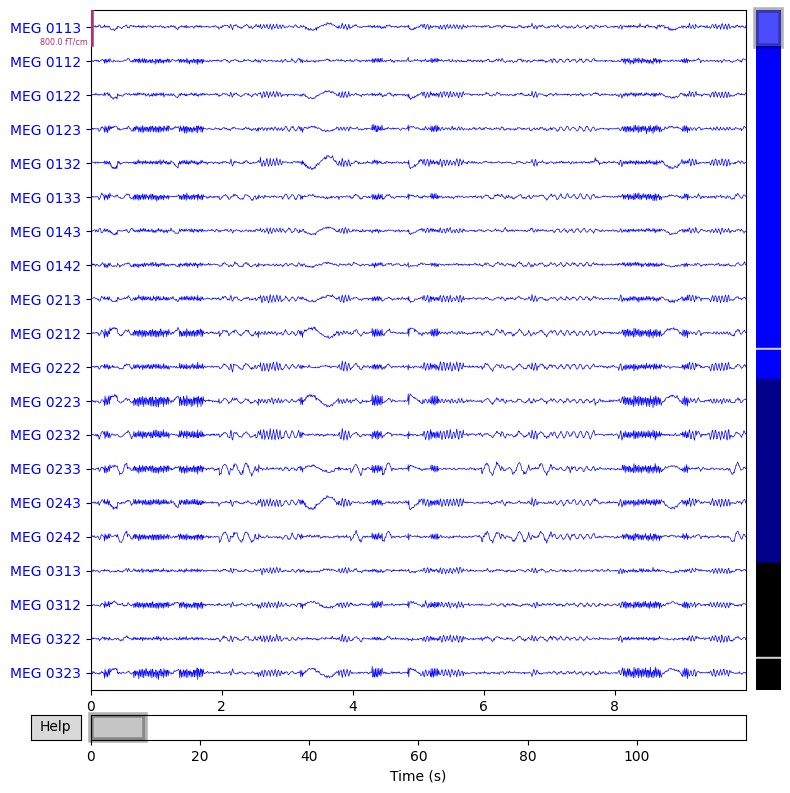

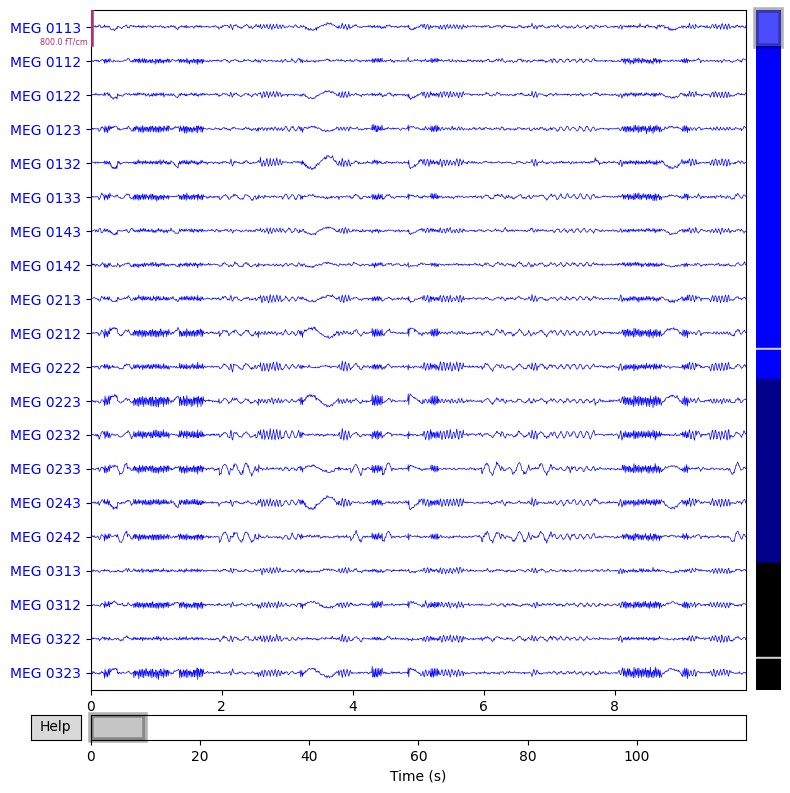

In [26]:
raw = mne.io.read_raw_fif('simulations/sim_000/raw.fif')
raw.plot()

/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


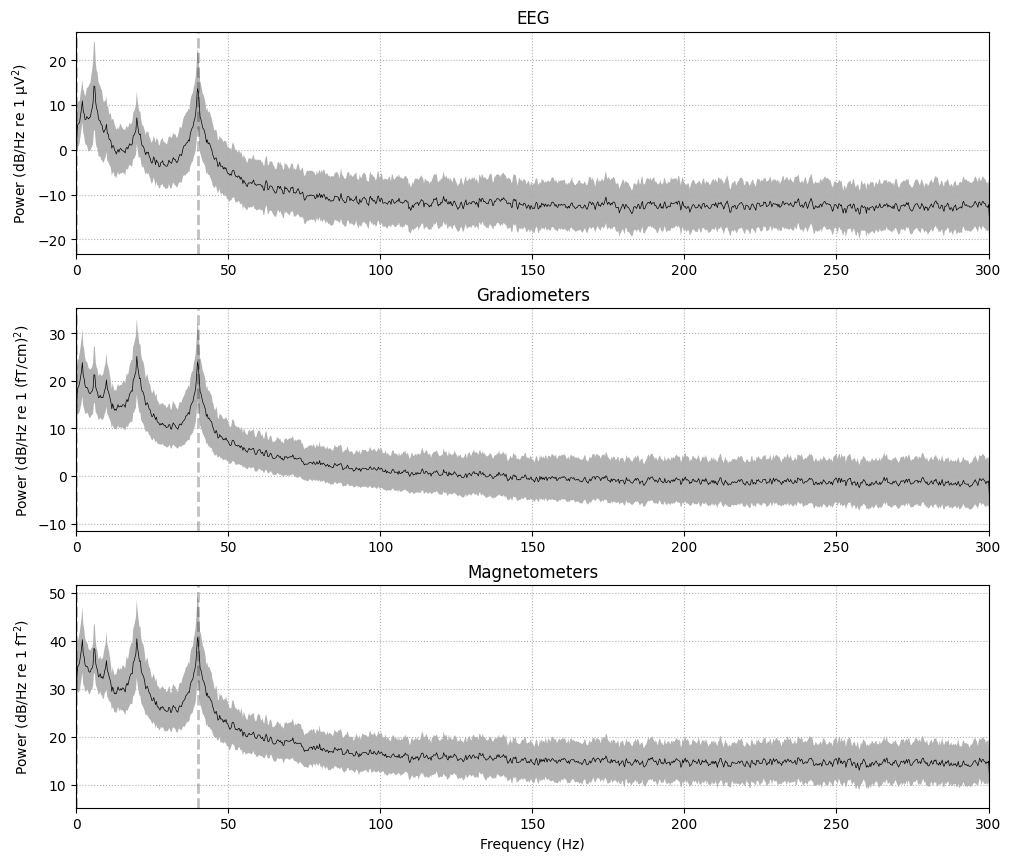

In [27]:
# Should have spike at 40 hz and 10 hz
spectrum = raw.compute_psd()
spectrum.plot(average=True, picks="data", exclude="bads", amplitude=False)

# Train TDE-HMM

In [28]:
# X_list is a 2D array where each internal list is the data for each simulation
# Y_list is a 2D array where each internal list is the corresponding ground-truth states for each simulation

def load_simulated_meg_for_hmm(sim_root="simulations"):
    X_list = []
    y_list = []

    sim_dirs = sorted(d for d in os.listdir(sim_root) if d.startswith("sim_"))

    for sim in sim_dirs:
        raw_path = f"{sim_root}/{sim}/raw.fif"
        label_path = f"{sim_root}/{sim}/state_labels.npy"

        raw = mne.io.read_raw_fif(raw_path, preload=True, verbose=False)
        first_20 = raw.ch_names[:20]
        raw.pick(first_20)

        orig_n = raw.n_times
        raw.resample(300)
        X_raw = raw.get_data().T
        new_n = X_raw.shape[0]

        labels = np.load(label_path)
        idx = (np.arange(new_n) * (orig_n / new_n)).astype(int)
        idx = np.clip(idx, 0, orig_n-1)
        labels_rs = labels[idx]

        X_list.append(X_raw)
        y_list.append(labels_rs)

    return X_list, y_list


In [29]:
X_list, y_list = load_simulated_meg_for_hmm()

In [30]:
# Concatenate everything and use the index data to keep track
X_concat = np.vstack(X_list) #simulation
y_concat = np.hstack(y_list) #state labels

In [31]:
idx_data = statistics.get_indices_from_list(X_list)

In [32]:
X_preproc = preproc.preprocess_data(X_concat, idx_data)[0]

### Sanity check plot

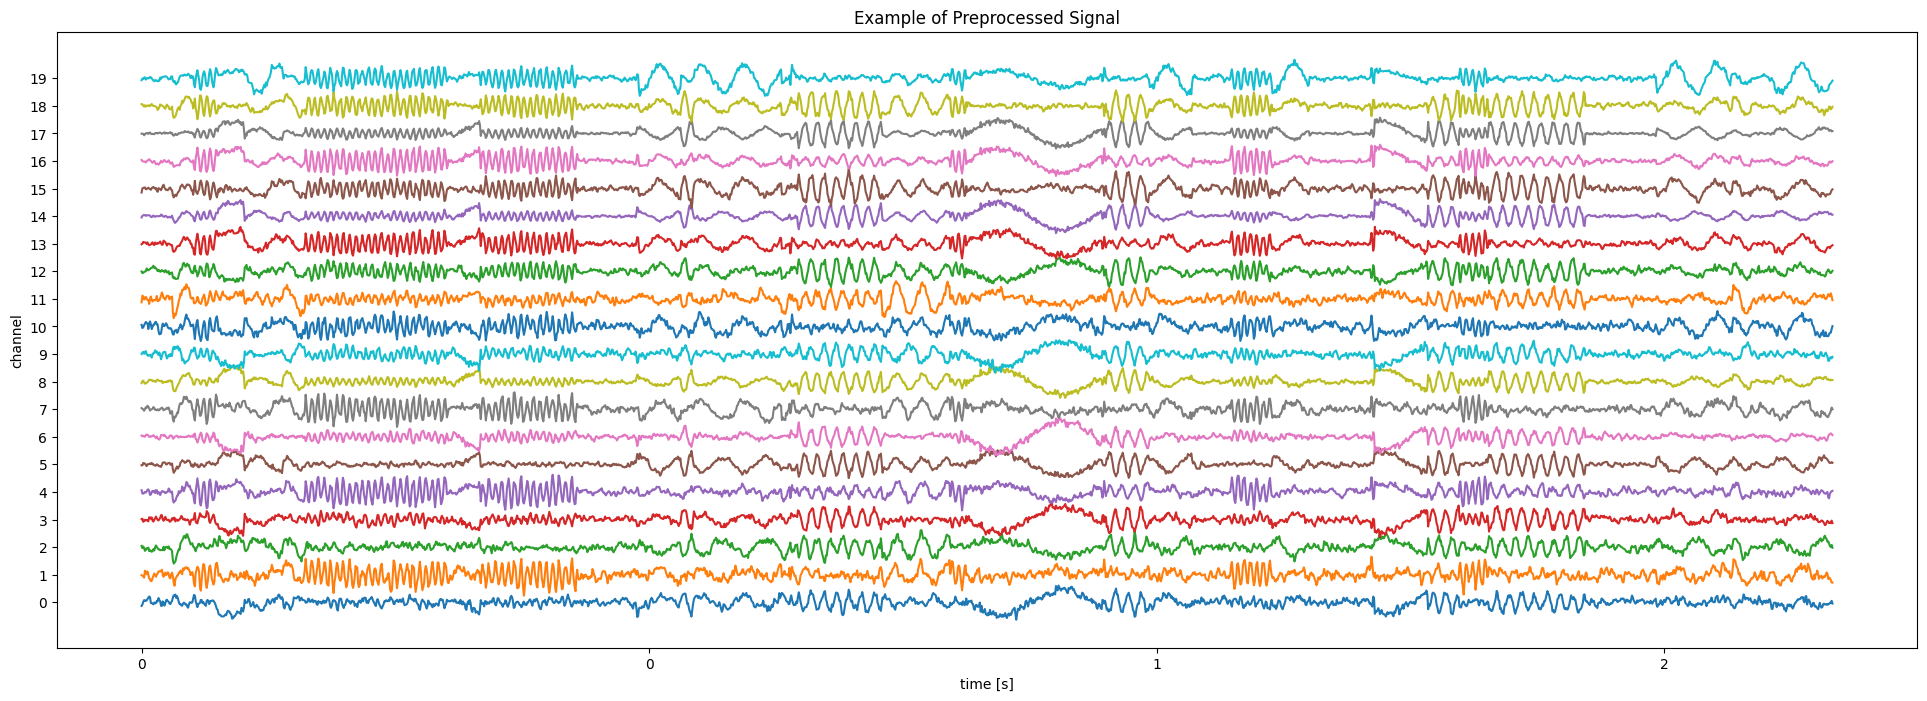

In [33]:
plot_range = np.arange(0, 2000)

Fs = info['sfreq']
tick_positions = np.arange(0, len(plot_range), int(Fs))
tick_labels = (tick_positions / Fs).astype(int)
n_regions = X_preproc.shape[1]

# plot each parcel separately
plt.close('all')
fig = plt.figure(figsize=(24,8))
for i in range(n_regions):
    plt.plot(X_preproc[plot_range,i]+i*5)

plt.xticks(tick_positions, tick_labels)
plt.xlabel('time [s]')
plt.yticks(np.arange(0,n_regions*5,5),np.arange(n_regions))
plt.ylabel('channel')
plt.title('Example of Preprocessed Signal')
plt.show()

### Apply TDE preprocessing


In [49]:
S = 1
L = 2
lags = np.arange(-L, L + 1, S)

X_embedded, idx_tde, pca_model = preproc.build_data_tde(X_preproc,idx_data,lags=lags, pca=2 * 20)

# Since we messed up X_preproc with this embedding stuff
# we need to fix the ground-truth labels to match correctly
# for when we calculate/compare with the ground truth
y_tde_list = []
for (s_tde, e_tde) in idx_tde:
    y_tde_list.append(y_concat[s_tde:e_tde])

y_tde = np.concatenate(y_tde_list)

assert len(y_tde) == X_embedded.shape[0], (f"Label mismatch: y={len(y_tde)}, X={X_embedded.shape[0]}")

/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/decomposition/_base.py:155: RuntimeWarning: divide by zero encountered in matmul
  X_transformed -= xp.reshape(self.mean_, (1, -1)) @ self.components_.T
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/decomposition/_base.py:155: RuntimeWarning: overflow encountered in matmul
  X_transformed -= xp.reshape(self.mea

In [ ]:
TDE_hmm = glhmm.glhmm(model_beta='no', model_mean='state', K=6, covtype='full') #change K := number of total states (in here, we have 6 states in total)

In [51]:
# train HMM
print('Training HMM-TDE')
stc_tde, xi_tde, fe_tde = TDE_hmm.train(X=None, Y=X_embedded, indices=idx_tde)
vpath_tde = TDE_hmm.decode(X=None, Y=X_embedded, viterbi=True)

Training HMM-TDE


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:136: RuntimeWarning: divide by zero encountered in matmul
  xi = Gamma[ind_1_1,:].T @ Gamma[ind_1_2,:]
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:136: RuntimeWarning: overflow encountered in matmul
  xi = Gamma[ind_1_1,:].T @ Gamma[ind_1_2,:]
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:136: RuntimeWarning: invalid value encountered in matmul
  xi = Gamma[ind_1_1,:].T @ Gamma[ind_1_2,:]
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/glhmm.py:822: RuntimeWarning: divide by zero encountered in matmul
  GY = np.expand_dims(Gm[:,k],axis=1).T @ Yr
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/glhmm.py:822: RuntimeWarning: overflow encountered in matmul
  GY = np.expand_dims(Gm[:,k],axis=1).T @ Yr
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/glh

Init repetition 1 free energy = 7681265.880646737


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:136: RuntimeWarning: divide by zero encountered in matmul
  xi = Gamma[ind_1_1,:].T @ Gamma[ind_1_2,:]
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:136: RuntimeWarning: overflow encountered in matmul
  xi = Gamma[ind_1_1,:].T @ Gamma[ind_1_2,:]
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:136: RuntimeWarning: invalid value encountered in matmul
  xi = Gamma[ind_1_1,:].T @ Gamma[ind_1_2,:]
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/glhmm.py:371: RuntimeWarning: divide by zero encountered in matmul
  else: Cd = d @ C
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/glhmm.py:371: RuntimeWarning: overflow encountered in matmul
  else: Cd = d @ C
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/glhmm.py:371: RuntimeWarning: invalid value encountered

Init repetition 2 free energy = 7666822.323768521


...

Cycle 16, free energy = 7531619.222129859, relative change = 7.387245205547977e-07


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2325: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2325: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2325: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:430: RuntimeWarning: divide by zero encountered in matmul
  D = 0.5 * (t1 - t2 - N + np.trace(isigma_p @ sigma_q) + ((d.T @ isigma_p) @ d))
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:430: RuntimeWarning: overflow encountered in matmul
 

Cycle 17, free energy = 7531619.22201499, relative change = 3.40019149244044e-07


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2325: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2325: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2325: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:430: RuntimeWarning: divide by zero encountered in matmul
  D = 0.5 * (t1 - t2 - N + np.trace(isigma_p @ sigma_q) + ((d.T @ isigma_p) @ d))
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/glhmm/auxiliary.py:430: RuntimeWarning: overflow encountered in matmul
 

Cycle 18, free energy = 7531619.22196931, relative change = 1.35213693668948e-07
Reached early convergence
Finished training in 59.81s : active states = 6


### Save the trained TDE-HMM

In [52]:
hmm_dict = {
    'hmm':TDE_hmm,
    'stc':stc_tde,
    'xi':xi_tde,'fe':fe_tde,'vpath':vpath_tde}
with open("./hmm_tde.pkl", "wb") as fp:
    pickle.dump(hmm_dict, fp, pickle.HIGHEST_PROTOCOL)

### Sanity check view the Viterbi path

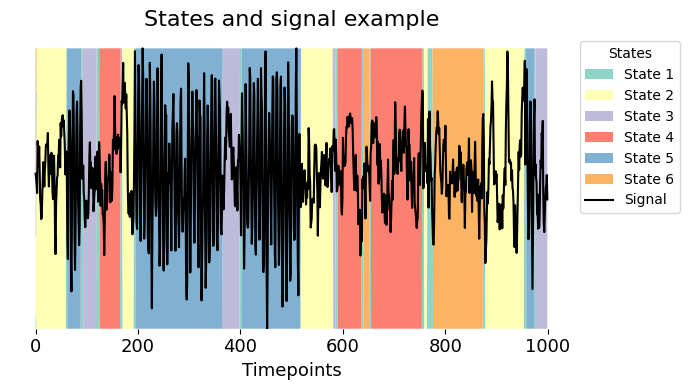

In [53]:
# apply the padGamma function to the vp to plot states and signal
T = auxiliary.get_T(idx_data)
options_tde = {'embeddedlags':list(lags)}
paddedVP = auxiliary.padGamma(vpath_tde, T, options_tde)

# plot state time courses with signal
plotting_range = np.arange(0, 1000)
graphics.plot_vpath(paddedVP[plotting_range], signal=X_preproc[plotting_range,1].copy(), title="States and signal example")

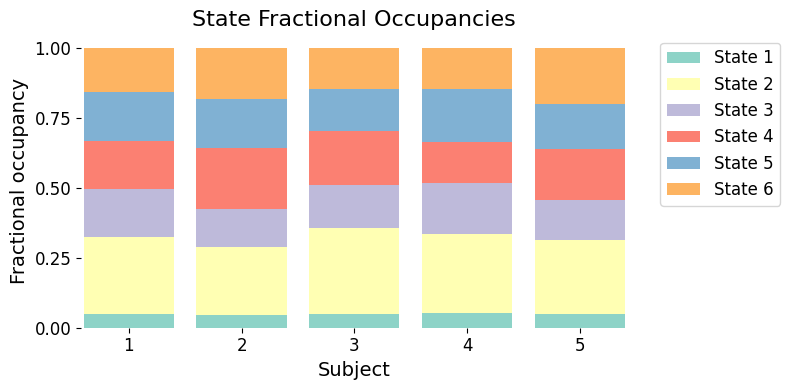

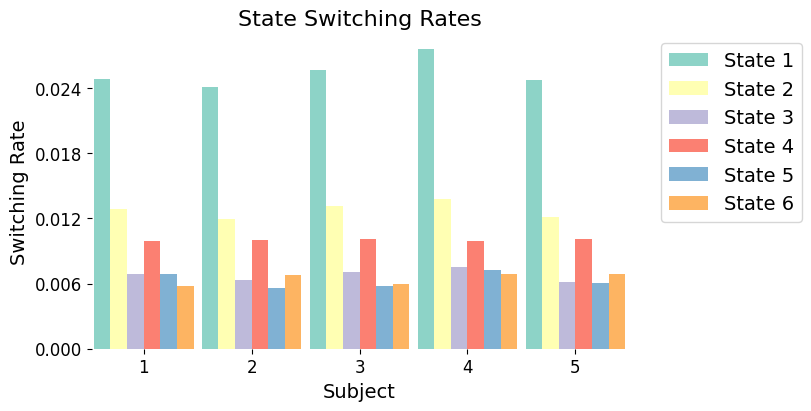

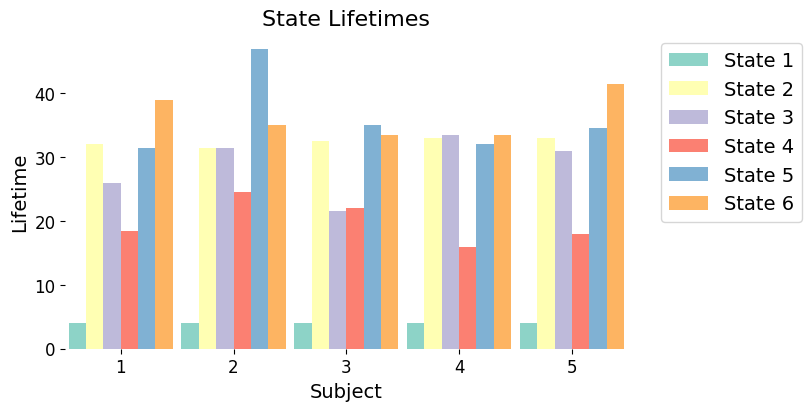

In [54]:
# inspect states - basic sanity checks
FO = utils.get_FO(stc_tde, indices=idx_tde)
SR = utils.get_switching_rate(stc_tde, indices=idx_tde)
LTmean, LTmed, LTmax = utils.get_life_times(vpath_tde, indices=idx_tde)

# plot some relevant statistics
graphics.plot_FO(FO)
graphics.plot_switching_rates(SR)
graphics.plot_state_lifetimes(LTmed)

### Verify HMM w/ Ground Truths

In [55]:
row_sums = vpath_tde.sum(axis=1)
assert np.allclose(row_sums, 1.0), "Some rows are not proper one-hot vectors!"

z = np.argmax(vpath_tde, axis=1).astype(int)

In [ ]:
n_states = vpath_tde.shape[1]  # returns number of total states => which is 6 in here

#hungarian match
C = confusion_matrix(y_tde, z, labels=range(n_states))
C_pred_true = C.T

cost = -C_pred_true
row_ind, col_ind = linear_sum_assignment(cost)
mapping = dict(zip(row_ind, col_ind))
print("HMM -> True mapping:", mapping)
#end of matching

z_mapped = np.vectorize(lambda s: mapping[s])(z)

C_mapped = confusion_matrix(y_tde, z_mapped, labels=range(n_states))
print("Mapped confusion matrix (true rows, predicted cols):")
print(C_mapped) #diagnoal: # of correct state predictions
#other cells: # of wrong state predictions (all after Hungarian Match performed)

accuracy = (z_mapped == y_tde).mean()
print(f"Accuracy after mapping: {accuracy:.3f}")

HMM -> True mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(5), np.int64(3): np.int64(4), np.int64(4): np.int64(2), np.int64(5): np.int64(3)}
Mapped confusion matrix (true rows, predicted cols):
[[  465 17987  1065  1228  3681  1068]
 [ 1612 22225   819   667   749   704]
 [ 1532  1196 23614   709   730   705]
 [ 1507  1093   729 22344   846   653]
 [ 1386  1151   678   758 22444   554]
 [ 1561  1194   644   699   740 22243]]
Accuracy after mapping: 0.700


### Plot Histogram to Compare Distribution of States

In [ ]:
# extract run durations for each state (ALWAYS include all states 0..K-1)
def get_run_lengths(seq, K=None):
    seq = np.asarray(seq)

    # If K not provided, infer from max label
    if K is None:
        K = int(np.max(seq)) + 1

    # Create keys for ALL states (even if some don't appear)
    run_lengths = {s: [] for s in range(K)}

    current_state = int(seq[0])
    length = 1

    for a, b in zip(seq[:-1], seq[1:]):
        if a == b:
            length += 1
        else:
            run_lengths[current_state].append(length)
            current_state = int(b)
            length = 1

    run_lengths[current_state].append(length)
    return run_lengths


def convert_to_seconds(run_dict, Fs):
    return {k: np.asarray(v, dtype=float) / Fs for k, v in run_dict.items()}

K = 6  # baseline + delta + theta + alpha + beta + gamma, update K to the current total number of states

true_runs = get_run_lengths(y_tde, K=K)
pred_runs = get_run_lengths(z_mapped, K=K)

true_sec = convert_to_seconds(true_runs, Fs=Fs)
pred_sec = convert_to_seconds(pred_runs, Fs=Fs)


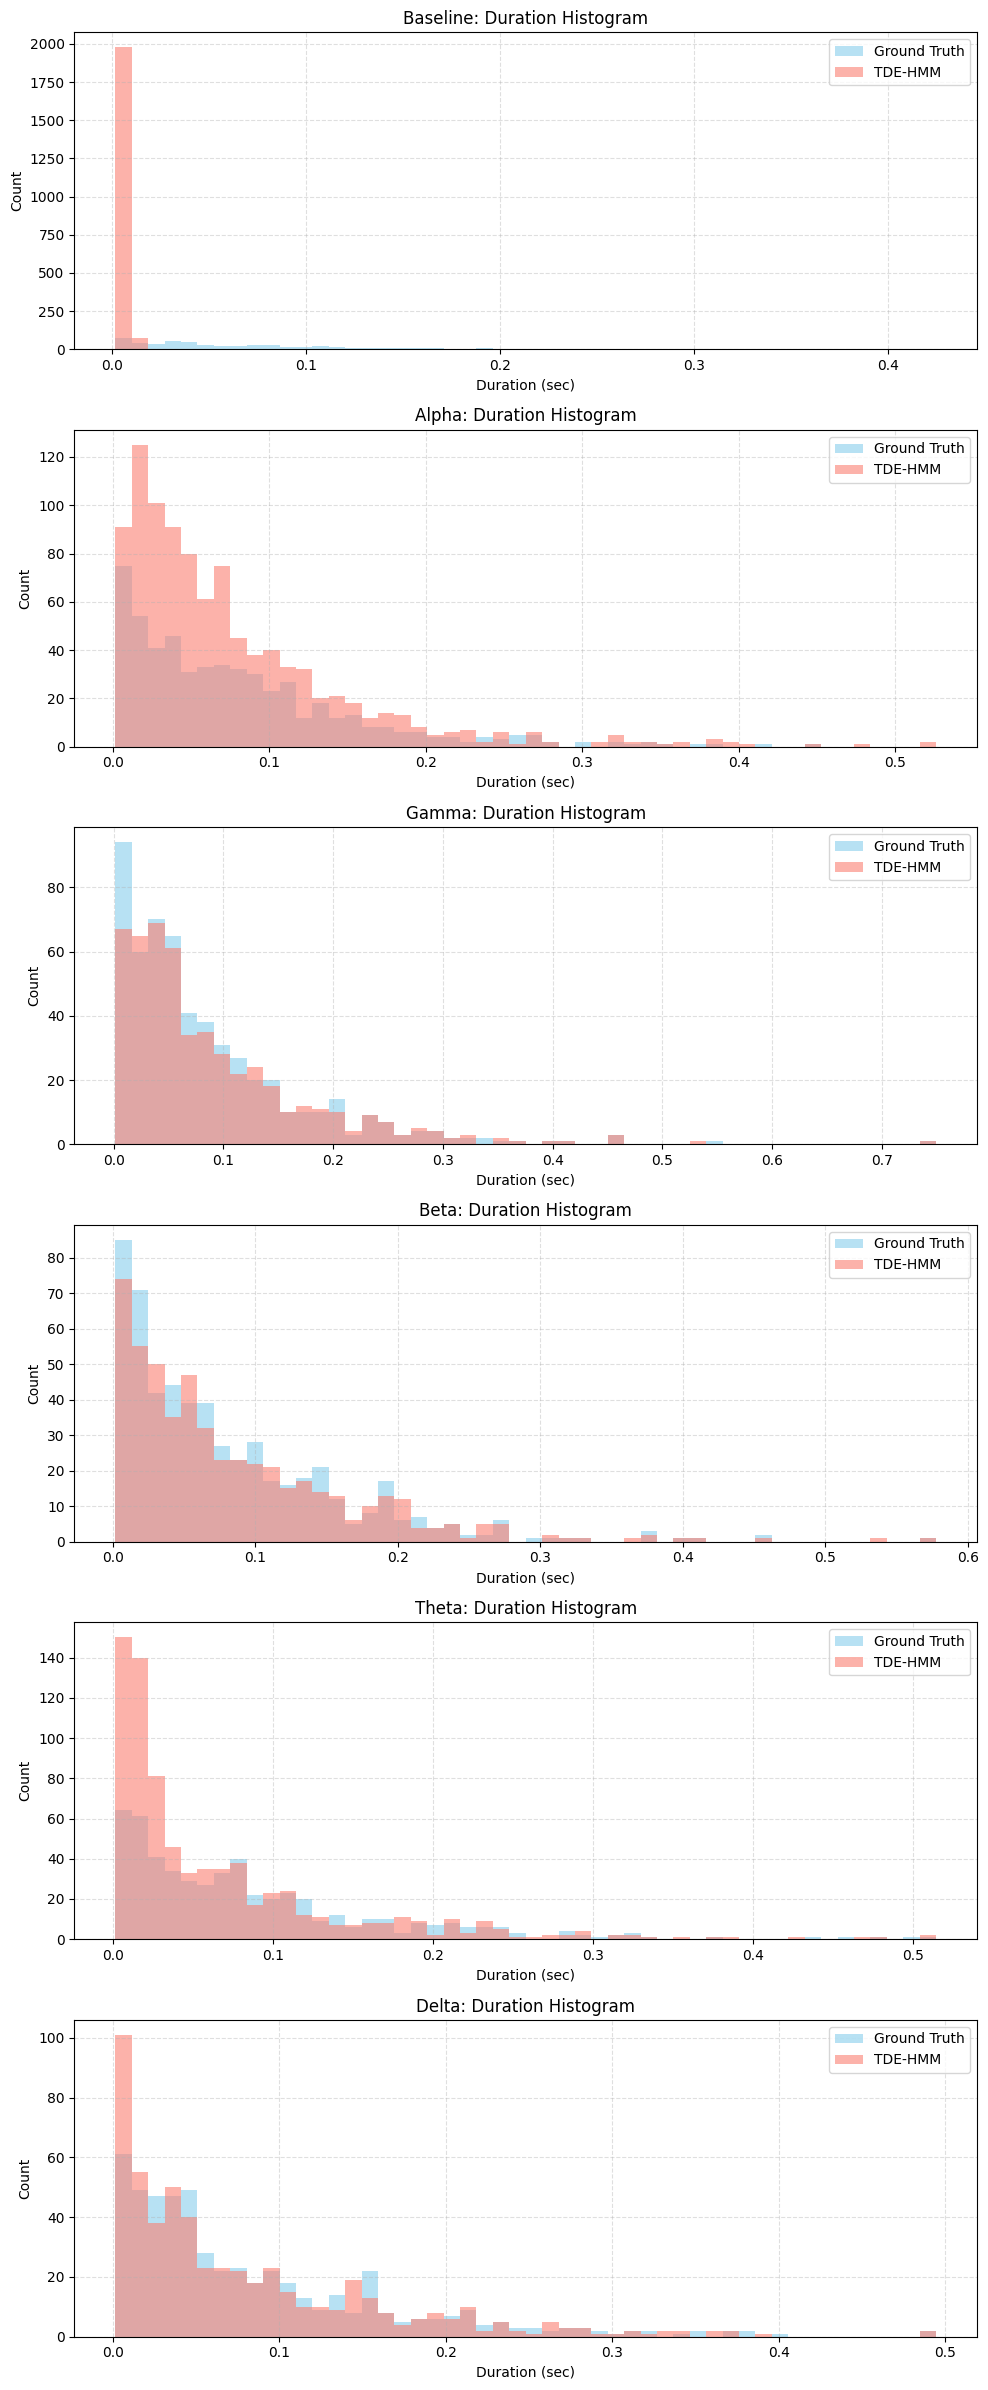

In [ ]:
def plot_hist_duration(true_sec, pred_sec, bins=50):

    # Map numeric states → meaningful labels
    # number of states && labe number must match to how you defined initially
    state_names = {
        0: "Baseline",
        1: "Alpha",
        2: "Gamma",
        3: "Beta",
        4: "Theta",
        5: "Delta"
    }

    # Plot all states that appear in either dictionary
    states = sorted(set(true_sec.keys()) | set(pred_sec.keys()))

    fig, ax = plt.subplots(len(states), 1, figsize=(10, 4 * len(states)))
    if len(states) == 1:
        ax = [ax]

    for i, s in enumerate(states):
        t = np.asarray(true_sec.get(s, []))
        p = np.asarray(pred_sec.get(s, []))

        # --- MATCHED BIN EDGES (key upgrade) ---
        if (t.size + p.size) > 0:
            all_data = np.concatenate([t, p]) if (t.size and p.size) else (t if t.size else p)
            bin_edges = (
                np.linspace(all_data.min(), all_data.max(), bins + 1)
                if all_data.size > 1 else bins
            )
        else:
            bin_edges = bins

        ax[i].hist(t, bins=bin_edges, alpha=0.6, label="Ground Truth", color="skyblue")
        ax[i].hist(p, bins=bin_edges, alpha=0.6, label="TDE-HMM", color="salmon")

        ax[i].set_title(f"{state_names.get(s, f'State {s}')}: Duration Histogram")
        ax[i].set_xlabel("Duration (sec)")
        ax[i].set_ylabel("Count")
        ax[i].legend()
        ax[i].grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()




plot_hist_duration(true_sec, pred_sec, bins=50)

### Plot heapmap for Confusion Matrix

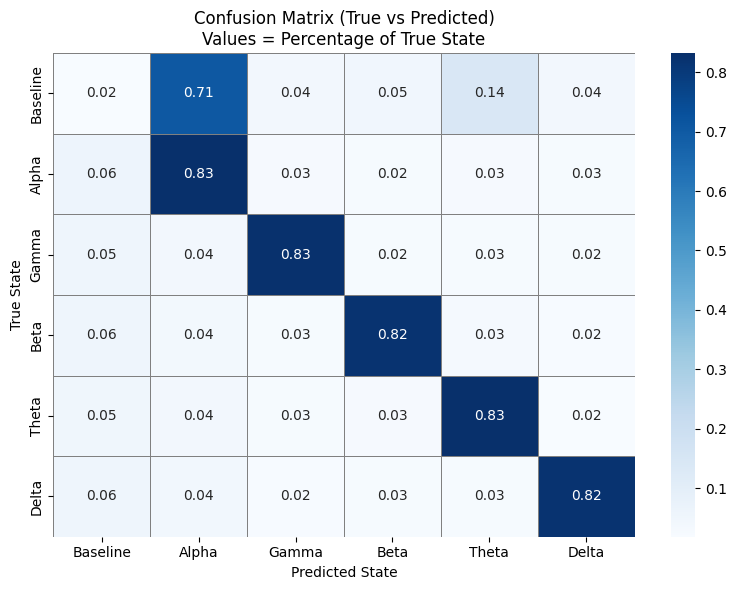

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_heatmap(C_mapped):
    # Convert counts → percentages
    C_pct = C_mapped / C_mapped.sum(axis=1, keepdims=True)

    # State name mapping (number of states must match total number of states)
    state_names = ["Baseline", "Alpha", "Gamma", "Beta", "Theta", "Delta"] #put states in the order of their corresponding label number (defined in plot_hist_duration)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        C_pct,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=state_names,
        yticklabels=state_names,
        linewidths=0.5,
        linecolor='gray'
    )

    plt.title("Confusion Matrix (True vs Predicted)\nValues = Percentage of True State")
    plt.xlabel("Predicted State")
    plt.ylabel("True State")
    plt.tight_layout()
    plt.show()

plot_confusion_heatmap(C_mapped)